In [1]:
import numpy as np
import cv2
import time
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans
from sklearn import cluster

In [2]:
_path1 = 'C:\\Users\\hp\\Desktop\\3\\5.bmp'
img = cv2.imread(_path1)
print(img.shape)

(600, 600, 3)


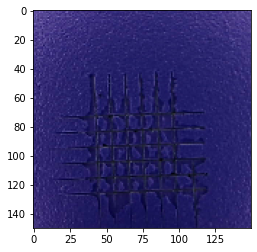

In [3]:
img2 = cv2.resize(img, (img.shape[1]//4, img.shape[0]//4))
plt.imshow(img2)

In [4]:
data = img2 / 255.0 # use 0...1 scale
data = data.reshape(-1, 3) # 展开成二维数组

data2 = img / 255.0
data2 = data2.reshape(-1,3)

In [5]:
_kmeans = MiniBatchKMeans(2)

In [6]:
_kmeans.fit(data) # 对颜色进行聚类

MiniBatchKMeans(n_clusters=2)

In [7]:
_spec = cluster.SpectralClustering(n_clusters=2)

In [ ]:
# _spec.fit(data)#内存不够

In [8]:
new_colors = _kmeans.cluster_centers_[_kmeans.predict(data2)] # 映射转换原图的颜色

In [9]:
img_recolored = new_colors.reshape(img.shape) # 新的二位颜色数组转为图像矩阵
img_recolored = (img_recolored*255).astype(np.uint8) # 转为8位图像

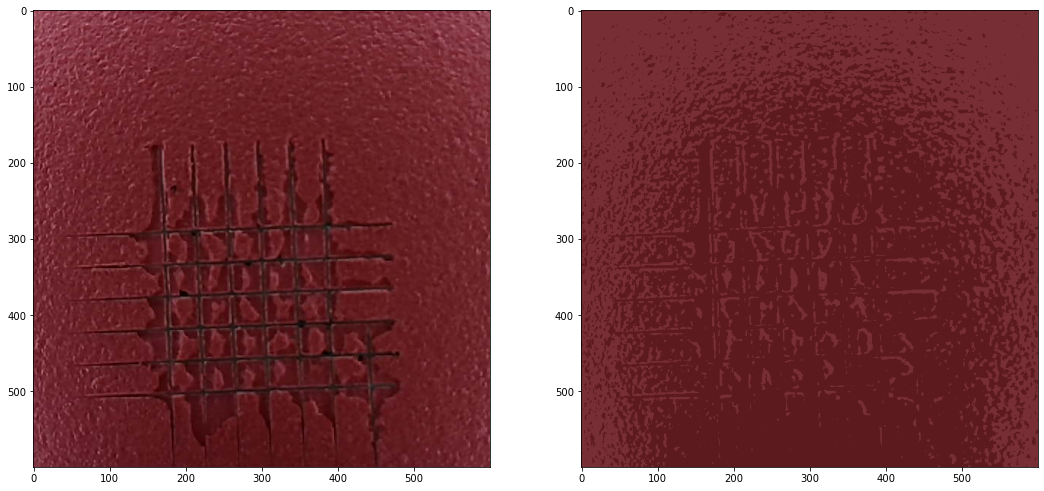

In [10]:
plt.figure(figsize=(18,12))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(img_recolored, cv2.COLOR_BGR2RGB))

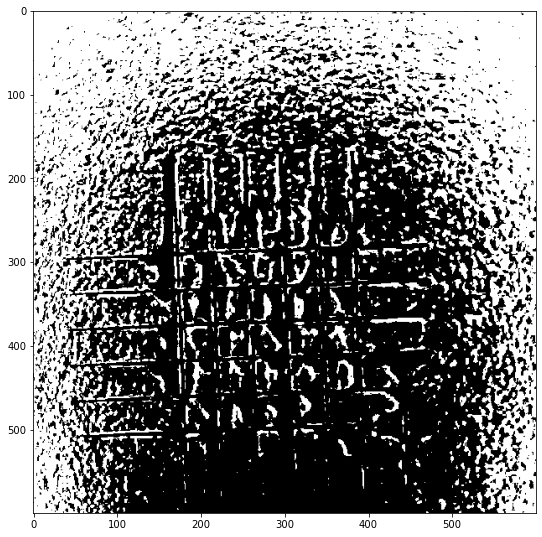

In [11]:
img_recolored_gray = cv2.cvtColor(img_recolored, cv2.COLOR_BGR2GRAY) # 转为灰度图，灰度值的个数为簇的个数
plt.figure(figsize=(9,12))
plt.imshow(img_recolored_gray, cmap='gray')